In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

from scipy.stats import uniform

import warnings
warnings.filterwarnings("ignore")

In [2]:
cancer = load_breast_cancer()

X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(cancer.target)

print("Número de registros:", X.shape[0])
print("Número de variables:", X.shape[1])

print("\nDistribución de clases:")
print(y.value_counts())

Número de registros: 569
Número de variables: 30

Distribución de clases:
1    357
0    212
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (455, 30)
Prueba: (114, 30)


Entrenamiento del Modelo

In [6]:
modelo = LogisticRegression(max_iter=5000)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:,1]

Matriz de Confusión

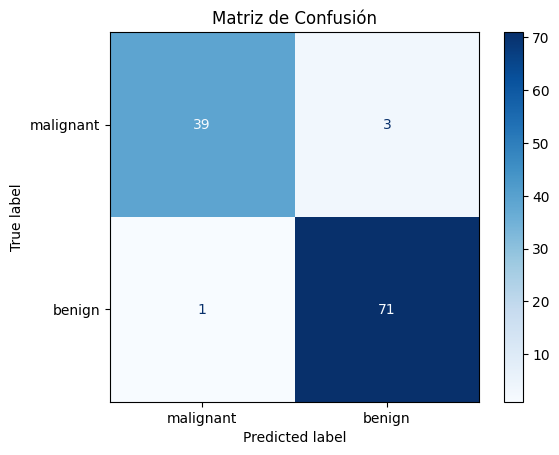

In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

Métricas de Evaluación

In [9]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1 Score:", round(f1,4))
print("AUC ROC:", round(auc,4))

Precision: 0.9595
Recall: 0.9861
F1 Score: 0.9726
AUC ROC: 0.9954


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



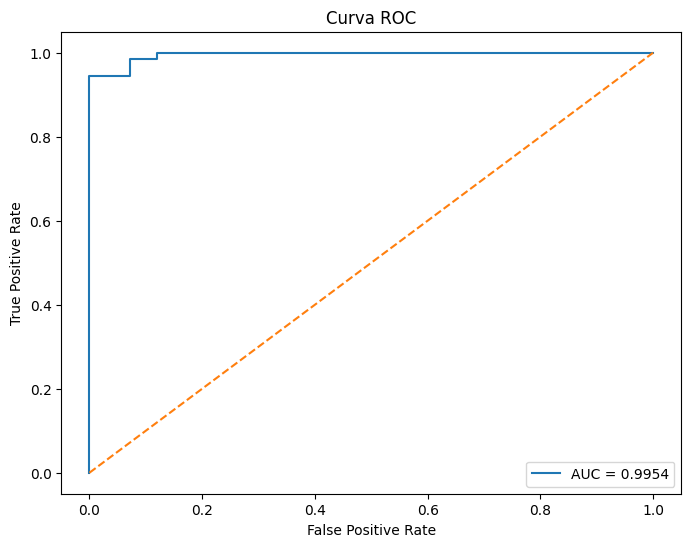

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

K-Fold Cross Validation (k=5)

In [12]:
scores_5 = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Resultados k=5")
print(scores_5)

print("Promedio:", scores_5.mean())

Resultados k=5
[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Promedio: 0.9507995652848935


K-Fold Cross Validation (k=10)

In [13]:
scores_10 = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("Resultados k=10")
print(scores_10)

print("Promedio:", scores_10.mean())

Resultados k=10
[0.98245614 0.9122807  0.92982456 0.94736842 0.98245614 0.98245614
 0.92982456 0.94736842 0.96491228 0.96428571]
Promedio: 0.9543233082706767


In [14]:
comparacion_cv = pd.DataFrame({
    "K":[5,10],
    "Accuracy Promedio":[
        scores_5.mean(),
        scores_10.mean()
    ],
    "Desviación Estándar":[
        scores_5.std(),
        scores_10.std()
    ]
})

comparacion_cv

,K,Accuracy Promedio,Desviación Estándar
0,5,0.950800,0.018041
1,10,0.954323,0.023771


GridSearchCV

In [16]:
param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

print("Mejor F1:")
print(grid.best_score_)

Mejores parámetros:
{'C': 10, 'solver': 'liblinear'}
Mejor F1:
0.9669354557334098


RandomizedSearchCV

In [17]:
param_dist = {
    'C': uniform(0.01,100)
}

random = RandomizedSearchCV(
    LogisticRegression(max_iter=5000),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42
)

random.fit(X_train, y_train)

print("Mejores parámetros:")
print(random.best_params_)

print("Mejor F1:")
print(random.best_score_)

Mejores parámetros:
{'C': np.float64(18.192496720710064)}
Mejor F1:
0.9702106119497425


Ajuste de Umbral (0.30)

In [18]:
y_pred_30 = (y_prob >= 0.30).astype(int)

precision_30 = precision_score(y_test,y_pred_30)
recall_30 = recall_score(y_test,y_pred_30)
f1_30 = f1_score(y_test,y_pred_30)

print("Precision:",precision_30)
print("Recall:",recall_30)
print("F1:",f1_30)

Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231


Ajuste de Umbral (0.50)

In [19]:
y_pred_50 = (y_prob >= 0.50).astype(int)

precision_50 = precision_score(y_test,y_pred_50)
recall_50 = recall_score(y_test,y_pred_50)
f1_50 = f1_score(y_test,y_pred_50)

print("Precision:",precision_50)
print("Recall:",recall_50)
print("F1:",f1_50)

Precision: 0.9594594594594594
Recall: 0.9861111111111112
F1: 0.9726027397260274


Ajuste de Umbral (0.70)

In [20]:
y_pred_70 = (y_prob >= 0.70).astype(int)

precision_70 = precision_score(y_test,y_pred_70)
recall_70 = recall_score(y_test,y_pred_70)
f1_70 = f1_score(y_test,y_pred_70)

print("Precision:",precision_70)
print("Recall:",recall_70)
print("F1:",f1_70)

Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1: 0.951048951048951


In [22]:
umbrales = pd.DataFrame({
    "Umbral":[0.3,0.5,0.7],
    "Precision":[precision_30,precision_50,precision_70],
    "Recall":[recall_30,recall_50,recall_70],
    "F1":[f1_30,f1_50,f1_70]
})

umbrales

,Umbral,Precision,Recall,F1
0,0.3,0.946667,0.986111,0.965986
1,0.5,0.959459,0.986111,0.972603
2,0.7,0.957746,0.944444,0.951049


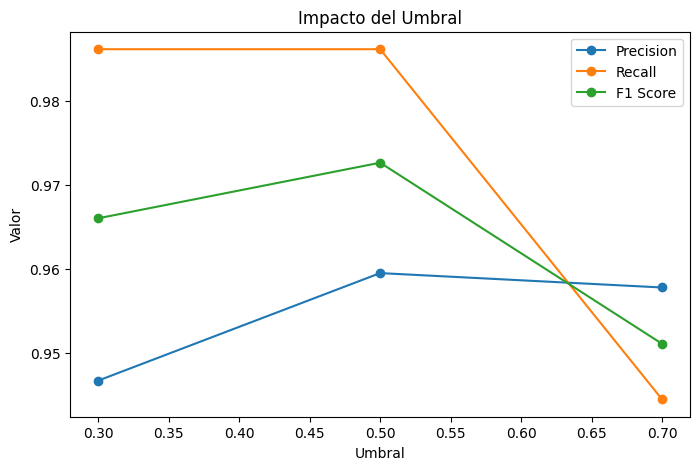

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    umbrales["Umbral"],
    umbrales["Precision"],
    marker='o',
    label='Precision'
)

plt.plot(
    umbrales["Umbral"],
    umbrales["Recall"],
    marker='o',
    label='Recall'
)

plt.plot(
    umbrales["Umbral"],
    umbrales["F1"],
    marker='o',
    label='F1 Score'
)

plt.title("Impacto del Umbral")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()

plt.show()